Code created by: Lorena Espinosa, Johana Rátiva, Eduards Chipatecua 

Class: Procesamiento del Lenguaje Natural

University: Universidad de los Andes

Date: October 10, 2026

In [70]:
# Importamos las librerías necesarias para el desarollo del laboratorio
import io
import random
import re

import kagglehub
from pathlib import Path

import seaborn as sns


import contextlib
import gzip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from tensorflow import keras
from keras import layers
from keras.utils import pad_sequences
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from gensim.models import Word2Vec

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Construcción del conjunto.

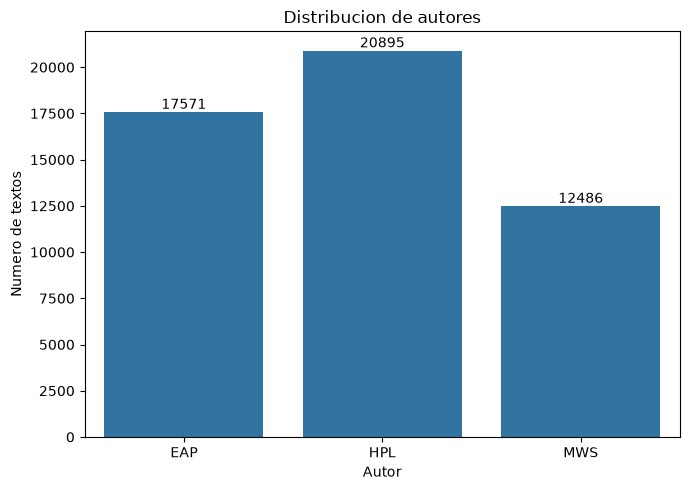

author
HPL    20895
EAP    17571
MWS    12486
Name: count, dtype: int64


In [71]:
"""Carga el conjunto de datos desde Kaggle. Guarda los textos y autores en un DataFrame. 
Luego muestra la cantidad de textos por autor."""

path = kagglehub.dataset_download("lteodor/identify-the-author")
csv_path = Path(path) / "labeled_sentence_corpus.csv"
df = pd.read_csv(csv_path)

plt.figure(figsize=(7, 5))

ax = sns.countplot(x="author", data=df)

plt.title("Distribucion de autores")
plt.xlabel("Autor")
plt.ylabel("Numero de textos")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

print(df["author"].value_counts())


In [ ]:
def construir_segmentos(df):
    segmentos = []
    min_palabras = 150
    max_palabras = 250

    for autor, grupo in df.groupby("author", sort=True):
        # Conservamos el orden original de las oraciones
        # y reunimos sus palabras sin perder ninguna.
        palabras_autor = []

        for oracion in grupo["text"].dropna():
            palabras_autor.extend(oracion.split())

        # Construimos segmentos de max 250 palabras.
        segmentos_autor = []

        for inicio in range(0, len(palabras_autor), max_palabras):
            fin = inicio + max_palabras
            segmento = palabras_autor[inicio:fin]
            segmentos_autor.append(segmento)

        # Revisamos si el ultimo segmento tiene menos de 150 palabras.
        if len(segmentos_autor) >= 2:
            ultimo = segmentos_autor[-1]
            penultimo = segmentos_autor[-2]

            if len(ultimo) < min_palabras:
                total = len(penultimo) + len(ultimo)

                # Intentamos redistribuir las palabras de los
                # dos ultimos segmentos sin incumplir los limites.
                if 2 * min_palabras <= total <= 2 * max_palabras:
                    palabras_combinadas = penultimo + ultimo

                    mitad = total // 2

                    segmentos_autor[-2] = palabras_combinadas[:mitad]
                    segmentos_autor[-1] = palabras_combinadas[mitad:]

        # Guardamos todos los segmentos, incluido cualquier
        # segmento final que tenga menos de 150 palabras -> evita la perdida de informacion
        for segmento in segmentos_autor:
            segmentos.append({
                "text": " ".join(segmento),
                "author": autor,
                "word_count": len(segmento)
            })

    return pd.DataFrame(
        segmentos,
        columns=["text", "author", "word_count"]
    )

df_segmentos = construir_segmentos(df)

print("Dimensiones del nuevo conjunto:", df_segmentos.shape)

print("\nCantidad de segmentos por autor:")
print(df_segmentos["author"].value_counts())

Dimensiones del nuevo conjunto: (5305, 3)

Cantidad de segmentos por autor:
author
HPL    2248
EAP    1754
MWS    1303
Name: count, dtype: int64


In [73]:
train_df, aux_df = train_test_split(
    df_segmentos,
    test_size=0.40,
    random_state=42,
    stratify=df_segmentos["author"],
)

val_df, test_df = train_test_split(
    aux_df,
    test_size=0.75,
    random_state=42,
    stratify=aux_df["author"],
)

print("Entrenamiento:", len(train_df), f"({len(train_df) / len(df_segmentos):.1%})")
print("Validación:", len(val_df), f"({len(val_df) / len(df_segmentos):.1%})")
print("Prueba:", len(test_df), f"({len(test_df) / len(df_segmentos):.1%})")

Entrenamiento: 3183 (60.0%)
Validación: 530 (10.0%)
Prueba: 1592 (30.0%)


# Representaciones.

Convertimos las palabras a minúsculas.

Separamos el texto en tokens.

Excluimos números y signos de puntuación.

 don't se convierte en don y t. P

In [74]:
def tokenizar_texto(texto):
    return re.findall(r"\b[a-z]+\b", str(texto).lower())
textos_train = train_df["text"].apply(tokenizar_texto).tolist()

## Modelos Wor2Vec

In [75]:
def entrenar_word2vec(texto, dim):
    return Word2Vec(
        sentences=texto,
        vector_size=dim,
        window=5,
        min_count=2,
        workers=4,
        sg=1,
        seed=42,
        epochs=10
    )

In [76]:
dimensiones = [50, 100, 200]

modelos_w2v = {}

for dimension in dimensiones:
    modelos_w2v[dimension] = entrenar_word2vec(
        textos_train,
        dimension
    )

    print(f"Word2Vec de {dimension} dimensiones entrenado.")

Word2Vec de 50 dimensiones entrenado.
Word2Vec de 100 dimensiones entrenado.
Word2Vec de 200 dimensiones entrenado.


In [77]:
for dimension, modelo in modelos_w2v.items():
    print(
        f"Dimensión: {dimension} | "
        f"Vocabulario: {len(modelo.wv)} | "
        f"Tamaño del vector: {modelo.wv.vector_size}"
    )

Dimensión: 50 | Vocabulario: 20349 | Tamaño del vector: 50
Dimensión: 100 | Vocabulario: 20349 | Tamaño del vector: 100
Dimensión: 200 | Vocabulario: 20349 | Tamaño del vector: 200


## Modelo GLove

In [78]:
def cargar_glove(dimension):
    filename = f"glove-wiki-gigaword-{dimension}.gz"

    url = (
        "https://github.com/RaRe-Technologies/gensim-data/releases/"
        f"download/glove-wiki-gigaword-{dimension}/"
        f"{filename}"
    )

    with contextlib.redirect_stdout(io.StringIO()):
        path = keras.utils.get_file(
            fname=filename,
            origin=url,
            cache_subdir="datasets",
        )

    return load_glove_vectors(path)

def load_glove_vectors(path):
    """Carga vectores en formato Word2Vec comprimido."""
    with gzip.open(path, "rt", encoding="utf-8") as file:
        number_of_words, vector_size = map(int, next(file).split())
        words = []
        vectors = np.empty((number_of_words, vector_size),dtype=np.float32,)

        for index, line in enumerate(file):
            word, values = line.rstrip().split(maxsplit=1)
            words.append(word)
            vectors[index] = np.fromstring(
                values,
                sep=" ",
                dtype=np.float32,
            )

    word_to_index = {
        word: index for index, word in enumerate(words)
    }
    vector_norms = np.linalg.norm(vectors, axis=1)
    return words, vectors, word_to_index, vector_norms

In [79]:
dimensiones = [50, 100, 200]

modelos_glove = {}

for dimension in dimensiones:
    (glove_words,glove_values,glove_index,glove_norms) = cargar_glove(dimension)

    modelos_glove[dimension] = {
        "words": glove_words,
        "values": glove_values,
        "index": glove_index,
        "norms": glove_norms,
    }

    print(f"GloVe de {dimension} dimensiones cargado.")

GloVe de 50 dimensiones cargado.
GloVe de 100 dimensiones cargado.
GloVe de 200 dimensiones cargado.


## Construccion del Vocabulario

In [ ]:
#Consturccion del vocabulario 
# Contar las apariciones de cada palabra
contador_palabras = Counter(
    palabra
    for texto in textos_train
    for palabra in texto
)

# 0 para el relleno y 1 para palabras desconocidas
vocabulario = {
    palabra: indice
    for indice, (palabra, _) in enumerate(
        contador_palabras.most_common(),
        start=2
    )
}
VOCABULARIO_SIZE = len(vocabulario) + 2
print("Tamaño del vocabulario:", VOCABULARIO_SIZE)

Tamaño del vocabulario: 31510


In [81]:
#Creo la representacion de cada oracion en numeros del vocabulario
def texto_to_secuencia(texto, vocabulario):
    tokens = tokenizar_texto(texto)

    return [
        vocabulario.get(palabra, 1)
        for palabra in tokens
    ]


secuencias_train = [
    texto_to_secuencia(texto, vocabulario)
    for texto in train_df["text"]
]

secuencias_val = [
    texto_to_secuencia(texto, vocabulario)
    for texto in val_df["text"]
]

secuencias_test = [
    texto_to_secuencia(texto, vocabulario)
    for texto in test_df["text"]
]

In [ ]:
longitudes = [len(secuencia) for secuencia in secuencias_train]

print("Longitud min:", min(longitudes))
print("Longitud max:", max(longitudes))
print("Longitud promedio:", sum(longitudes) / len(longitudes))

Longitud mínima: 171
Longitud máxima: 281
Longitud promedio: 253.02136349355953


La logitud maxima es de 281, esto puede ser causado por la tockenizacion, lo cual hace necesario rellenear y reseleccionar un nuevo maximo, para que todos los segmentos de entrenamiento sean uniformes -> Seleccione 300

300 es superior a la longitud maxima observada de 281, por lo que no perderemos palabras de los segmentos actuales y es una longitud uniforme que podemos utilizar para todos los textos.

Usamos padding="post" para añadir los ceros al final y truncating="post" para eliminar el exceso al final si alguna secuencia supera los 300 tokens.

In [83]:
MAX_LONGITUD = 300

X_train = pad_sequences(
    secuencias_train,
    maxlen=MAX_LONGITUD,
    padding="post",
    truncating="post",
    value=0
)

X_val = pad_sequences(
    secuencias_val,
    maxlen=MAX_LONGITUD,
    padding="post",
    truncating="post",
    value=0
)

X_test = pad_sequences(
    secuencias_test,
    maxlen=MAX_LONGITUD,
    padding="post",
    truncating="post",
    value=0
)

print("Entrenamiento:", X_train.shape)
print("Validación:", X_val.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (3183, 300)
Validación: (530, 300)
Prueba: (1592, 300)


- EAP → 0
- HPL → 1
- MWS → 2

In [84]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df["author"])
y_val = encoder.transform(val_df["author"])
y_test = encoder.transform(test_df["author"])

print("Autores:", encoder.classes_)

Autores: ['EAP' 'HPL' 'MWS']


## Creación de matrices 

In [85]:
def crear_matriz_word2vec(modelo_w2v, dimension):
    matriz = np.random.uniform(
        -0.05, 0.05,
        size=(VOCABULARIO_SIZE, dimension)
    ).astype(np.float32)

    palabras_encontradas = 0

    for palabra, indice in vocabulario.items():
        if palabra in modelo_w2v.wv:
            matriz[indice] = modelo_w2v.wv[palabra]
            palabras_encontradas += 1

    print(
        f"Dimensión {dimension}: "
        f"{palabras_encontradas} de {len(vocabulario)} palabras "
        "encontradas en Word2Vec."
    )

    return matriz

def crear_matriz_glove(modelo_glove, dimension):
    matriz = np.random.uniform(
        -0.05, 0.05,
        size=(VOCABULARIO_SIZE, dimension)
    ).astype(np.float32)

    palabras_encontradas = 0

    for palabra, indice in vocabulario.items():
        indice_glove = modelo_glove["index"].get(palabra)

        if indice_glove is not None:
            matriz[indice] = modelo_glove["values"][indice_glove]
            palabras_encontradas += 1

    print(
        f"Dimensión {dimension}: "
        f"{palabras_encontradas} de {len(vocabulario)} palabras "
        "encontradas en GloVe."
    )

    return matriz

In [86]:
matrices_w2v = {}
matrices_glove = {}
for dimension in dimensiones:
    matrices_w2v[dimension] = crear_matriz_word2vec(
        modelos_w2v[dimension],
        dimension
    )
    print(
           f"\n Forma de la matriz Word2Vec ({dimension}):",
           matrices_w2v[dimension].shape
       )
    matrices_glove[dimension] = crear_matriz_glove(
        modelos_glove[dimension],
        dimension
    )
   
    print(
            f"\n Forma de la matriz Glove ({dimension}):",
            matrices_glove[dimension].shape
        )

Dimensión 50: 20349 de 31508 palabras encontradas en Word2Vec.

 Forma de la matriz Word2Vec (50): (31510, 50)
Dimensión 50: 27456 de 31508 palabras encontradas en GloVe.

 Forma de la matriz Glove (50): (31510, 50)
Dimensión 100: 20349 de 31508 palabras encontradas en Word2Vec.

 Forma de la matriz Word2Vec (100): (31510, 100)
Dimensión 100: 27456 de 31508 palabras encontradas en GloVe.

 Forma de la matriz Glove (100): (31510, 100)
Dimensión 200: 20349 de 31508 palabras encontradas en Word2Vec.

 Forma de la matriz Word2Vec (200): (31510, 200)
Dimensión 200: 27456 de 31508 palabras encontradas en GloVe.

 Forma de la matriz Glove (200): (31510, 200)


# Red neuronal

## Creacion del modelo

In [87]:
def crear_modelo(dimension, tipo_embedding, matriz_embedding=None):

    if tipo_embedding == "aprendido":
        capa_embedding = layers.Embedding(
            input_dim=VOCABULARIO_SIZE,
            output_dim=dimension,
            embeddings_initializer=keras.initializers.RandomUniform(
                seed=SEED
            ),
            mask_zero=True,
            trainable=True,
            name="learned_embedding"
        )

    elif tipo_embedding in ("word2vec", "glove"):
        if matriz_embedding is None:
           return  "error"

        if matriz_embedding.shape != (VOCABULARIO_SIZE, dimension):
            return "error"
        
        capa_embedding = layers.Embedding(
            input_dim=VOCABULARIO_SIZE,
            output_dim=dimension,
            weights=[matriz_embedding],
            mask_zero=True,
            trainable=False,
            name=f"{tipo_embedding}_embedding"
        )

    else:
        return "error"

    modelo = keras.Sequential([
        layers.Input(shape=(MAX_LONGITUD,), dtype=tf.int64),
        capa_embedding,
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu",bias_initializer="zeros"), #mayor capacidad de aprendizaje 
        layers.Dropout(0.2, seed=SEED),
        layers.Dense(3, activation="softmax", bias_initializer="zeros")
    ])

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return modelo


In [88]:
modelo_aprendido = crear_modelo(
    dimension=50,
    tipo_embedding="aprendido"
)

modelo_w2v = crear_modelo(
    dimension=50,
    tipo_embedding="word2vec",
    matriz_embedding=matrices_w2v[50]
)

modelo_glove = crear_modelo(
    dimension=50,
    tipo_embedding="glove",
    matriz_embedding=matrices_glove[50]
)

print("Los tres modelos se construyeron correctamente.")

Los tres modelos se construyeron correctamente.


In [89]:
#Comprobar tamaños y clases 
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nNúmero de clases:", len(encoder.classes_))
print("Autores:", encoder.classes_)

X_train: (3183, 300)
y_train: (3183,)
X_val: (530, 300)
y_val: (530,)
X_test: (1592, 300)
y_test: (1592,)

Número de clases: 3
Autores: ['EAP' 'HPL' 'MWS']


## Entrenar el Modelo

In [90]:
EPOCHS = 15
BATCH_SIZE = 32
SEED = 42

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

def entrenar_modelo(dimension, tipo_embedding, matriz_embedding=None):

    # Construir el modelo
    modelo = crear_modelo(
        dimension=dimension,
        tipo_embedding=tipo_embedding,
        matriz_embedding=matriz_embedding
    )

    # Entrenar el modelo
    historial = modelo.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping],
        verbose=1
    )

    return modelo, historial

In [ ]:
modelos = {}
historiales = {}

for tipo_embedding in ["aprendido", "word2vec", "glove"]:
    for dimension in dimensiones:

        clave = (tipo_embedding, dimension)

        if clave in modelos:
            continue

        print(
            f"\nEntrenando modelo: {tipo_embedding}, "
            f"dimensión {dimension}"
        )

        if tipo_embedding == "aprendido":
            matriz = None

        elif tipo_embedding == "word2vec":
            matriz = matrices_w2v[dimension]

        else:
            matriz = matrices_glove[dimension]

        modelo, historial = entrenar_modelo(
            dimension=dimension,
            tipo_embedding=tipo_embedding,
            matriz_embedding=matriz
        )

        modelos[clave] = modelo
        historiales[clave] = historial

print("\nEntrenamiento finalizado.")
print("Modelos entrenados:", len(modelos))


Entrenando modelo: aprendido, dimensión 50
Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5115 - loss: 0.9690 - val_accuracy: 0.8679 - val_loss: 0.7033
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9428 - loss: 0.3814 - val_accuracy: 0.9849 - val_loss: 0.1712
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9912 - loss: 0.0957 - val_accuracy: 0.9943 - val_loss: 0.0678
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9969 - loss: 0.0375 - val_accuracy: 1.0000 - val_loss: 0.0377
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9994 - loss: 0.0189 - val_accuracy: 1.0000 - val_loss: 0.0250
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9997 - loss: 0.0116 - val_accuracy: 1.0000 - val_loss: 0.0187
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9997 - loss: 0.0073 - val_accuracy: 1.0000 - val_loss: 0.0155
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accura

Es raro que aparezca acuraccy de 100% por lo tanto se hace comprobacion de los datasets

In [92]:
# 1. Comprobar si existen segmentos idénticos entre entrenamiento y validación
textos_train_set = set(train_df["text"].str.strip())
textos_val_set = set(val_df["text"].str.strip())

textos_compartidos = textos_train_set.intersection(textos_val_set)

tabla_duplicados = pd.DataFrame({
    "Comprobación": [
        "Segmentos únicos en entrenamiento",
        "Segmentos únicos en validación",
        "Segmentos idénticos compartidos"
    ],
    "Resultado": [
        len(textos_train_set),
        len(textos_val_set),
        len(textos_compartidos)
    ]
})

display(tabla_duplicados)


# 2. Comprobar la distribución de autores en cada conjunto
conjuntos = {
    "Entrenamiento": train_df,
    "Validación": val_df,
    "Prueba": test_df
}

tabla_distribucion = pd.DataFrame()

for nombre, conjunto in conjuntos.items():
    cantidades = conjunto["author"].value_counts()
    proporciones = conjunto["author"].value_counts(normalize=True)

    for autor in sorted(train_df["author"].unique()):
        tabla_distribucion = pd.concat([
            tabla_distribucion,
            pd.DataFrame([{
                "Conjunto": nombre,
                "Autor": autor,
                "Cantidad de segmentos": cantidades.get(autor, 0),
                "Proporción": proporciones.get(autor, 0)
            }])
        ], ignore_index=True)

tabla_distribucion["Proporción"] = (
    tabla_distribucion["Proporción"].round(3)
)

display(tabla_distribucion)

,Comprobación,Resultado
0,Segmentos únicos en entrenamiento,3183
1,Segmentos únicos en validación,530
2,Segmentos idénticos compartidos,0


,Conjunto,Autor,Cantidad de segmentos,Proporción
0,Entrenamiento,EAP,1052,0.331
1,Entrenamiento,HPL,1349,0.424
2,Entrenamiento,MWS,782,0.246
3,Validación,EAP,175,0.330
4,Validación,HPL,225,0.425
5,Validación,MWS,130,0.245
6,Prueba,EAP,527,0.331
7,Prueba,HPL,674,0.423
8,Prueba,MWS,391,0.246


In [ ]:
#Crear un resumen de los resultados de las validaciones
resultados_validacion = []

for (tipo_embedding, dimension), historial in historiales.items():
    mejor_epoca = (
        historial.history["val_loss"].index(
            min(historial.history["val_loss"])
        )
    )

    resultados_validacion.append({
        "Embedding": tipo_embedding,
        "Dimensión": dimension,
        "Época seleccionada": mejor_epoca + 1,
        "Precisión de validación": (
            historial.history["val_accuracy"][mejor_epoca]
        ),
        "Pérdida de validación": (
            historial.history["val_loss"][mejor_epoca]
        )
    })

tabla_validacion = pd.DataFrame(resultados_validacion)

tabla_validacion = tabla_validacion.sort_values(
    ["Embedding", "Dimensión"]
).reset_index(drop=True)

tabla_validacion

,Embedding,Dimensión,Época seleccionada,Precisión de validación,Pérdida de validación
0,aprendido,50,15,1.000000,0.005909
1,aprendido,100,15,1.000000,0.005709
2,aprendido,200,15,1.000000,0.004331
3,glove,50,15,0.883019,0.303633
4,glove,100,15,0.924528,0.234323
5,glove,200,15,0.947170,0.148413
6,word2vec,50,15,0.990566,0.056482
7,word2vec,100,15,0.998113,0.038244
8,word2vec,200,15,0.996226,0.030625


# Evaluación y comparación.

In [94]:
modelos_seleccionados = {
    "Aprendido (200)": modelos[("aprendido", 200)],
    "Word2Vec (200)": modelos[("word2vec", 200)],
    "GloVe (200)": modelos[("glove", 200)]
}

resultados_test = []
predicciones_test = {}

for nombre, modelo in modelos_seleccionados.items():

    probabilidades = modelo.predict(X_test, verbose=0)
    predicciones = np.argmax(probabilidades, axis=1)

    predicciones_test[nombre] = predicciones

    resultados_test.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, predicciones),
        "Precision macro": precision_score(
            y_test, predicciones, average="macro", zero_division=0
        ),
        "Recall macro": recall_score(
            y_test, predicciones, average="macro", zero_division=0
        ),
        "F1 macro": f1_score(
            y_test, predicciones, average="macro", zero_division=0
        ),
        "F1 micro": f1_score(
            y_test, predicciones, average="micro", zero_division=0
        )
    })

tabla_test = pd.DataFrame(resultados_test)

tabla_test = tabla_test.round(4)

tabla_test

,Modelo,Accuracy,Precision macro,Recall macro,F1 macro,F1 micro
0,Aprendido (200),0.9969,0.9963,0.9964,0.9964,0.9969
1,Word2Vec (200),0.9893,0.9895,0.9874,0.9883,0.9893
2,GloVe (200),0.9441,0.9450,0.9461,0.9451,0.9441


In [95]:
for nombre, predicciones in predicciones_test.items():

    print(f"\n{'=' * 50}")
    print(nombre)
    print("=" * 50)

    print(
        classification_report(
            y_test,
            predicciones,
            labels=np.arange(len(encoder.classes_)),
            target_names=encoder.classes_,
            digits=4,
            zero_division=0
        )
    )


Aprendido (200)
              precision    recall  f1-score   support

         EAP     0.9981    0.9943    0.9962       527
         HPL     0.9985    1.0000    0.9993       674
         MWS     0.9923    0.9949    0.9936       391

    accuracy                         0.9969      1592
   macro avg     0.9963    0.9964    0.9964      1592
weighted avg     0.9969    0.9969    0.9969      1592


Word2Vec (200)
              precision    recall  f1-score   support

         EAP     0.9740    0.9962    0.9850       527
         HPL     0.9970    0.9941    0.9955       674
         MWS     0.9974    0.9719    0.9845       391

    accuracy                         0.9893      1592
   macro avg     0.9895    0.9874    0.9883      1592
weighted avg     0.9895    0.9893    0.9893      1592


GloVe (200)
              precision    recall  f1-score   support

         EAP     0.8964    0.9526    0.9236       527
         HPL     0.9721    0.9318    0.9515       674
         MWS     0.9663    0.

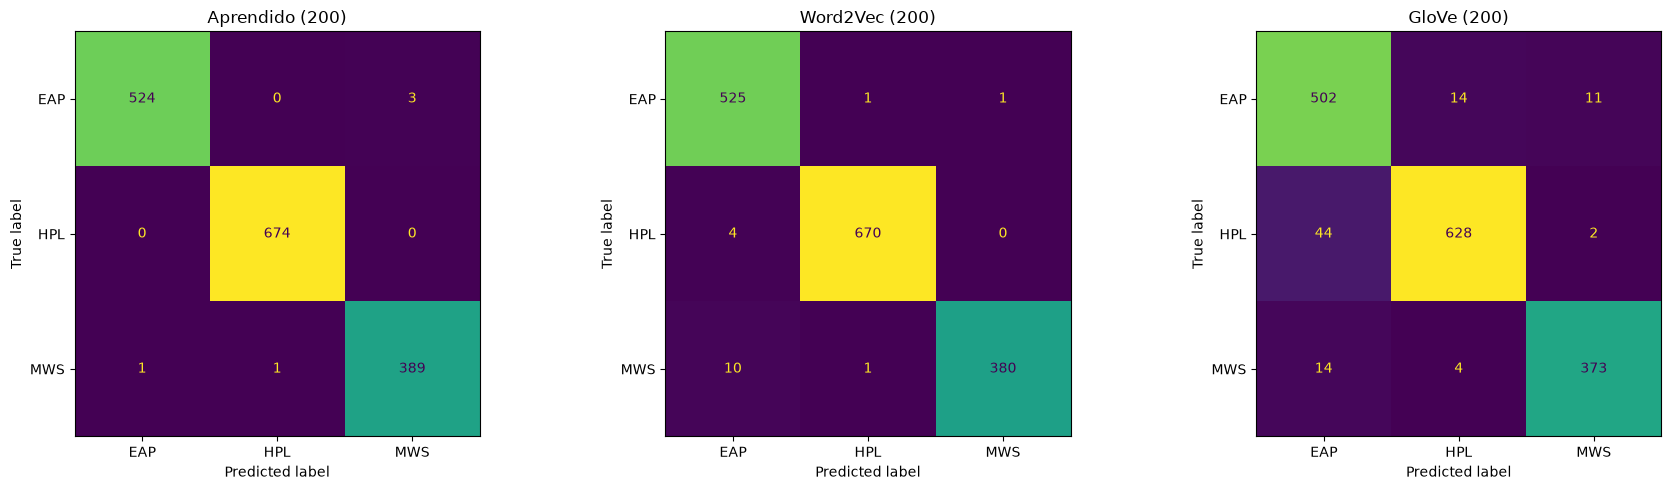

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, predicciones) in zip(
    axes, predicciones_test.items()
):
    cm = confusion_matrix(
        y_test,
        predicciones,
        labels=np.arange(len(encoder.classes_))
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=encoder.classes_
    )

    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(nombre)

plt.tight_layout()
plt.show()